In [102]:
import pandas as pd
import torch.nn as nn
from torchvision import transforms, datasets, models
import seaborn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset

In [103]:
df = pd.read_csv("../Data/stock.csv").dropna()
df

,Date,Adj Close,Close,High,Low,Open,Volume
0,1/2/2018,4.929880,4.983750,4.987500,4.862500,4.894500,355616000
1,1/3/2018,5.254335,5.311750,5.342500,5.093750,5.102500,914704000
2,1/4/2018,5.282033,5.339750,5.451250,5.317250,5.394000,583268000
3,1/5/2018,5.326794,5.385000,5.422750,5.277000,5.354750,580124000
4,1/8/2018,5.490012,5.550000,5.625000,5.464500,5.510000,881216000
...,...,...,...,...,...,...,...
1692,9/24/2024,120.861671,120.870003,121.800003,115.379997,116.519997,354966800
1693,9/25/2024,123.501495,123.510002,124.940002,121.610001,122.019997,284692900
1694,9/26/2024,124.031456,124.040001,127.669998,121.800003,126.800003,302582900
1695,9/27/2024,121.391640,121.400002,124.029999,119.260002,123.970001,271009200


<Axes: >

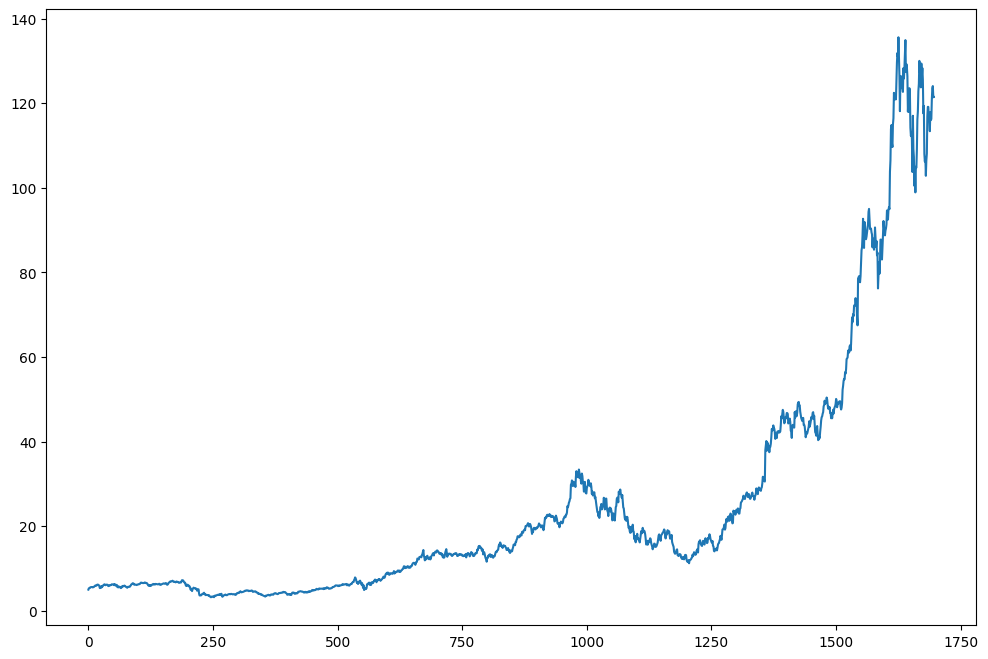

In [104]:
df.Close.plot(figsize=(12, 8))

In [105]:
df.dtypes

Date          object
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object

In [106]:
scaler = MinMaxScaler(feature_range=(0, 1))
df_close = scaler.fit_transform(df['Close'].values.reshape(-1, 1))

In [107]:
def new_seq(data, seq_length):
    sequences = []
    labels = []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i+seq_length])
        labels.append(data[i+seq_length])
    return np.array(sequences), np.array(labels)

seq_length = 50
X, y = new_seq(df_close, seq_length)

In [108]:
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

In [109]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

In [110]:
input_size = 1
hidden_size = 64
num_layers = 2
output_size = 1

model = LSTMModel(input_size, hidden_size, num_layers, output_size)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [111]:
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [112]:
train_data = StockDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(dataset=train_data, batch_size=50, shuffle=True)

In [113]:
num_epochs = 80
for epoch in range(num_epochs):
    model.train()
    for sequences, labels in train_loader:
        outputs = model(sequences)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}')

Epoch 1/80, Loss: 0.0021
Epoch 2/80, Loss: 0.0002
Epoch 3/80, Loss: 0.0001
Epoch 4/80, Loss: 0.0001
Epoch 5/80, Loss: 0.0000
Epoch 6/80, Loss: 0.0001
Epoch 7/80, Loss: 0.0001
Epoch 8/80, Loss: 0.0001
Epoch 9/80, Loss: 0.0002
Epoch 10/80, Loss: 0.0002
Epoch 11/80, Loss: 0.0000
Epoch 12/80, Loss: 0.0001
Epoch 13/80, Loss: 0.0002
Epoch 14/80, Loss: 0.0001
Epoch 15/80, Loss: 0.0001
Epoch 16/80, Loss: 0.0001
Epoch 17/80, Loss: 0.0000
Epoch 18/80, Loss: 0.0000
Epoch 19/80, Loss: 0.0001
Epoch 20/80, Loss: 0.0001
Epoch 21/80, Loss: 0.0000
Epoch 22/80, Loss: 0.0000
Epoch 23/80, Loss: 0.0000
Epoch 24/80, Loss: 0.0002
Epoch 25/80, Loss: 0.0000
Epoch 26/80, Loss: 0.0000
Epoch 27/80, Loss: 0.0000
Epoch 28/80, Loss: 0.0001
Epoch 29/80, Loss: 0.0000
Epoch 30/80, Loss: 0.0000
Epoch 31/80, Loss: 0.0001
Epoch 32/80, Loss: 0.0000
Epoch 33/80, Loss: 0.0000
Epoch 34/80, Loss: 0.0000
Epoch 35/80, Loss: 0.0001
Epoch 36/80, Loss: 0.0000
Epoch 37/80, Loss: 0.0000
Epoch 38/80, Loss: 0.0000
Epoch 39/80, Loss: 0.

In [122]:
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor)
    predictions = predictions.detach().numpy()
    predictions = scaler.inverse_transform(predictions)
    y_test = y_test_tensor.numpy()
    y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

preds = predictions.reshape(-1, 1)
true = y_test.reshape(-1, 1)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

round(mean_absolute_error(true, preds), 2), round(r2_score(true, preds), 2)

(5.24, 0.96)

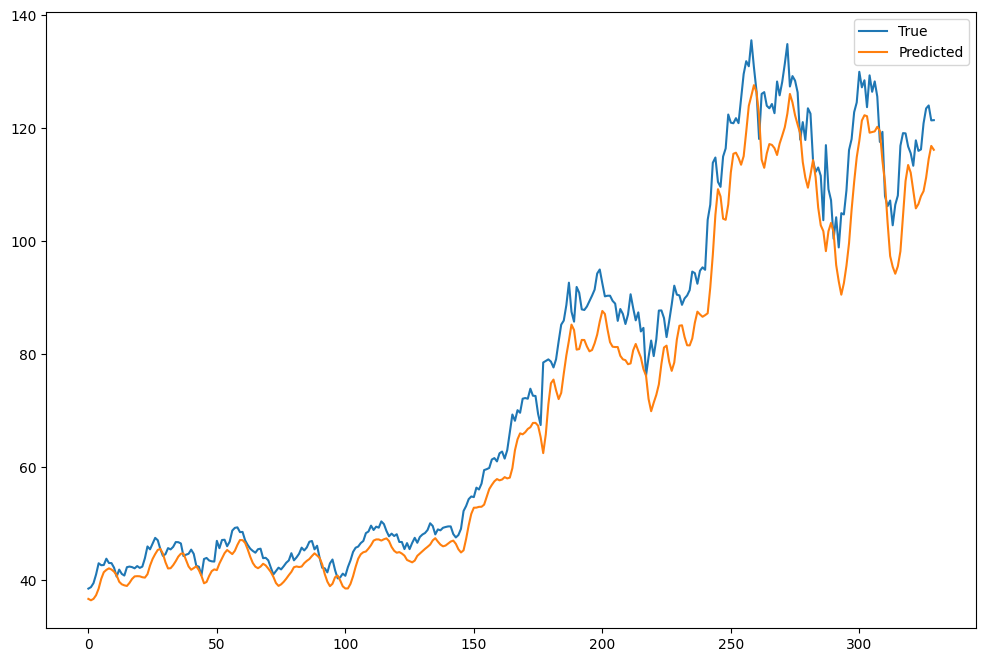

In [124]:
plt.figure(figsize=(12, 8))
plt.plot(y_test, label='True')
plt.plot(predictions, label='Predicted')
plt.legend()
plt.show()

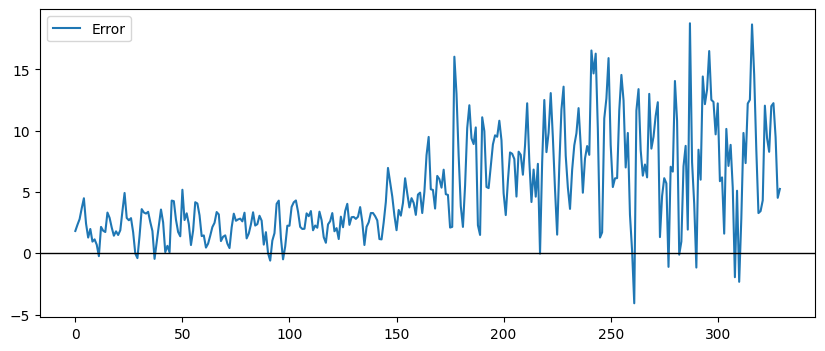

In [125]:
plt.figure(figsize=(10, 4))
plt.plot(true - preds, label='Error')
plt.axhline(0, color='black', linewidth=1)
plt.legend()
plt.show()

In [127]:
import joblib
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']